# CCA-based celltype label transfer (scRNA → scATAC)

Reproduces ArchR's `addGeneIntegrationMatrix` workflow: canonical
correlation analysis (CCA) between the scATAC gene-score matrix and a
matched scRNA reference, followed by kNN-based label transfer. This is
how ArchR's bookdown figures get their `HSC / Ery / GMP / B / T` cell
type labels — they come from the Granja et al. 2019 BMMC scRNA
reference, not from the ATAC clustering itself.

**Pipeline**
1. Load the 3-sample BMMC ATAC gene-score AnnData
   (`pbmc_gene_act.h5ad`, output of `t_integrate.ipynb` —
   ~10 k cells × 20 k genes).
2. Load the Granja 2019 BMMC scRNA reference
   (`granja2019_bmmc_scrna.h5ad` — 35,582 cells × 20,287 genes, with
   `obs['BioClassification']` hematopoietic labels).
3. Normalise both; pick their shared HVGs.
4. Run `cca_py.run_cca_anndata(atac, rna, ...)` → both objects get
   a shared `obsm['X_cca']`.
5. kNN in CCA space → transfer the majority-vote
   `BioClassification` label from RNA to each ATAC cell.
6. Save annotated ATAC + transfer-confidence scores.

The annotated ATAC from (6) feeds straight into TF footprint
analysis (`t_footprint.ipynb`) or any other per-celltype ATAC
workflow.

## Part 1 · Setup

In [1]:
import pathlib
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
from scipy import sparse
from sklearn.neighbors import NearestNeighbors
from collections import Counter
import matplotlib.pyplot as plt
from IPython.display import display

import epione as epi
from cca_py import run_cca_anndata

epi.pl.plot_set()

WORK = pathlib.Path.cwd() / 'data'
OUT  = pathlib.Path.cwd() / 'label_transfer'
OUT.mkdir(exist_ok=True)

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Impor

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Impor

└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.



## Part 2 · Load scRNA reference

The Granja 2019 BMMC scRNA RDS was converted to h5ad once (see
`scripts/convert_granja2019.R` next to the tutorials) — this cell
just reads the result.

In [2]:
rna = ad.read_h5ad('/scratch/users/steorra/data/archr_heme/granja2019_bmmc_scrna.h5ad')
print(rna)
print('\nBioClassification distribution:')
print(rna.obs['BioClassification'].value_counts().head(15))

AnnData object with n_obs × n_vars = 35582 × 20287
    obs: 'Group', 'nUMI_pre', 'nUMI', 'nGene', 'initialClusters', 'UMAP1', 'UMAP2', 'Clusters', 'BioClassification', 'Barcode'
    var: 'gene_name', 'gene_id', 'exonLength'

BioClassification distribution:
BioClassification
12_CD14.Mono.2    4222
22_CD4.M          3539
20_CD4.N1         2470
21_CD4.N2         2364
05_CMP.LMPP       2260
25_NK             2143
07_GMP            2097
24_CD8.CM         2080
11_CD14.Mono.1    1800
17_B              1711
02_Early.Eryth    1653
19_CD8.N          1521
01_HSC            1425
08_GMP.Neut       1050
06_CLP.1           903
Name: count, dtype: int64


## Part 3 · Load the 3-sample ATAC gene-score matrix

`t_integrate` built this at `pbmc_gene_act.h5ad` — one row per
ATAC cell, columns are **gene-score** values (ArchR-style
distance-weighted tile signal per gene). Barcodes are in
`<sample>#<barcode>` format.

In [3]:
atac = ad.read_h5ad(WORK / 'pbmc_gene_act.h5ad')
print(atac)
print('\nATAC obs cols:', list(atac.obs.columns))
# Barcodes already <sample>#<barcode>.

AnnData object with n_obs × n_vars = 10889 × 20109
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'sample', 'leiden'
    var: 'gene_name'
    obsm: 'X_lsi', 'X_lsi_harmony', 'X_umap'
    obsp: 'connectivities', 'distances'

ATAC obs cols: ['n_fragment', 'frac_dup', 'frac_mito', 'sample', 'leiden']


## Part 4 · Preprocess both sides

Standard pipeline:
1. normalise total counts + log1p
2. scanpy HVG per dataset
3. intersect HVG gene names — this is the shared feature set CCA
   projects into

ArchR does the same preprocessing via
``FindVariableFeatures/NormalizeData`` inside
``addGeneIntegrationMatrix``.

In [4]:
# log-normalise + HVG per dataset
for ad_obj, name in [(rna, 'RNA'), (atac, 'ATAC')]:
    sc.pp.normalize_total(ad_obj, target_sum=1e4)
    sc.pp.log1p(ad_obj)
    sc.pp.highly_variable_genes(ad_obj, n_top_genes=3000, subset=False)
    print(f'{name}: {ad_obj.shape}  '
          f'HVG={int(ad_obj.var["highly_variable"].sum()):,}')

# Shared HVG genes (intersection of HVG from both).
hvg_shared = sorted(
    set(rna.var_names[rna.var['highly_variable']]) &
    set(atac.var_names[atac.var['highly_variable']])
)
print(f'\nshared HVG : {len(hvg_shared):,}')

normalizing counts per cell


    finished (0:00:00)


extracting highly variable genes


    finished (0:00:00)


--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


...

    finished (0:00:00)


extracting highly variable genes


    finished (0:00:00)


--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


ATAC: (10889, 20109)  HVG=3,000

shared HVG : 563


## Part 5 · Run CCA

`cca_py.run_cca_anndata` standardises each dataset on the shared
HVG set, does a thin SVD on `X^T @ Y`, and writes the left / right
canonical factors back to each object's `obsm['X_cca']`. 30
components is the ArchR default.

In [5]:
%%time
res = run_cca_anndata(
    atac, rna,
    features=hvg_shared,
    num_cc=30,
    standardize_inputs=True,
    key_added='X_cca',
    seed=42,
)
print(f'\nATAC X_cca: {atac.obsm["X_cca"].shape}')
print(f'RNA  X_cca: {rna.obsm["X_cca"].shape}')


ATAC X_cca: (10889, 30)
RNA  X_cca: (35582, 30)
CPU times: user 4min 27s, sys: 903 ms, total: 4min 28s
Wall time: 21.3 s


## Part 6 · kNN label transfer

For each ATAC cell, find its `k=30` nearest RNA cells in CCA space
and assign the **majority-vote** `BioClassification` label. Record
the vote fraction as a **transfer confidence** score — values < 0.5
flag cells where the top celltype narrowly won; these are usually
ATAC cells sitting between two RNA clusters and worth treating with
caution downstream.

In [6]:
%%time
K = 30
nn = NearestNeighbors(n_neighbors=K, metric='cosine')
nn.fit(rna.obsm['X_cca'])
dist, idx = nn.kneighbors(atac.obsm['X_cca'])
print(f'kNN done: {idx.shape}')

rna_labels = rna.obs['BioClassification'].astype(str).values
transferred = []
confidence  = []
for i in range(atac.n_obs):
    neigh_labels = rna_labels[idx[i]]
    top, votes = Counter(neigh_labels).most_common(1)[0]
    transferred.append(top)
    confidence.append(votes / K)
atac.obs['celltype_cca']      = pd.Categorical(transferred)
atac.obs['transfer_score']    = np.asarray(confidence, dtype=np.float32)

# Collapse the numeric-prefixed labels (e.g. "02_Early.Eryth") into
# simpler names if a ``_``-separated prefix is present.
atac.obs['celltype'] = atac.obs['celltype_cca'].astype(str).str.replace(
    r'^\d+_', '', regex=True)
print()
print('transferred label distribution:')
print(atac.obs['celltype'].value_counts().head(20))
print()
print('transfer score stats:')
print(atac.obs['transfer_score'].describe().round(3))

kNN done: (10889, 30)

transferred label distribution:
celltype
CD4.M          1719
CD14.Mono.2    1233
NK             1064
B               812
CD4.N1          705
GMP             633
CMP.LMPP        627
CD4.N2          619
Early.Eryth     598
HSC             507
CD8.CM          377
Pre.B           355
CLP.1           320
pDC             272
CD8.N           240
GMP.Neut        231
Late.Eryth      140
CD14.Mono.1     128
CD16.Mono       114
CLP.2            97
Name: count, dtype: int64

transfer score stats:
count    10889.000
mean         0.420
std          0.172
min          0.100
25%          0.300
50%          0.400
75%          0.500
max          1.000
Name: transfer_score, dtype: float64
CPU times: user 8.73 s, sys: 3.79 s, total: 12.5 s
Wall time: 5.89 s


## Part 7 · QC plots

- per-celltype cell counts
- transfer-score distribution
- optional: joint UMAP coloured by celltype

A well-behaved transfer shows a unimodal score distribution peaked
near 1 (high confidence), with a long tail only for genuine inter-
celltype boundary cells.

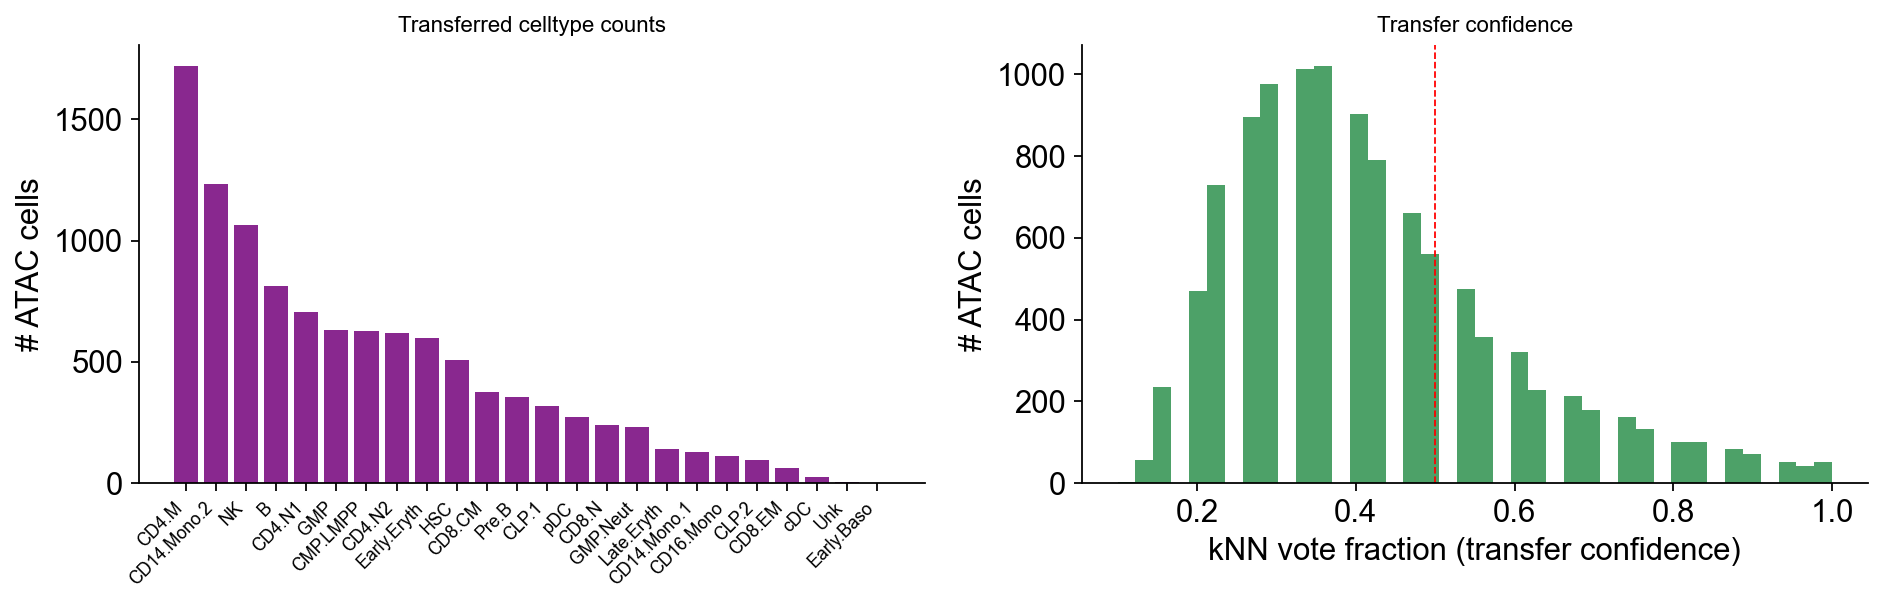

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# Cell-count bar
counts = atac.obs['celltype'].value_counts()
ax1.bar(range(len(counts)), counts.values, color='#89288F')
ax1.set_xticks(range(len(counts)))
ax1.set_xticklabels(counts.index, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('# ATAC cells')
ax1.set_title('Transferred celltype counts', fontsize=10)
ax1.spines[['top','right']].set_visible(False)
# Score histogram
ax2.hist(atac.obs['transfer_score'], bins=40, color='#208A42', alpha=0.8)
ax2.set_xlabel('kNN vote fraction (transfer confidence)')
ax2.set_ylabel('# ATAC cells')
ax2.set_title('Transfer confidence', fontsize=10)
ax2.axvline(0.5, color='red', lw=0.8, ls='--')
ax2.spines[['top','right']].set_visible(False)
plt.tight_layout(); display(fig); plt.close(fig)

## Part 8 · Save annotated ATAC

Write a compact AnnData carrying just obs/obsm/uns of the
annotated gene-score matrix (dropping X, since the raw gene
scores already live in `pbmc_gene_act.h5ad`). Downstream
footprint / peak-matrix workflows re-read fragments from
`uns['files']['fragments']`.

In [8]:
out_h5 = OUT / 'atac_bmmc_cca_annotated.h5ad'
keep = ad.AnnData(
    X=sparse.csr_matrix((atac.n_obs, 0), dtype=np.float32),
    obs=atac.obs[['sample','celltype','celltype_cca','transfer_score']].copy(),
    obsm={'X_cca': atac.obsm['X_cca']},
    uns={'files': {'fragments': 'data/pbmc_combined.fragments.tsv.gz'}},
)
keep.obs_names = atac.obs_names
keep.write_h5ad(out_h5)
print(f'saved {out_h5}  ({out_h5.stat().st_size/1e6:.1f} MB)')
print()
print('Sanity: celltype cross-tab with existing heuristic label (t_integrate):')
try:
    old = ad.read_h5ad(WORK / 'pbmc_peak_mat_anno.h5ad').obs.loc[atac.obs_names, 'celltype']
    print(pd.crosstab(old, atac.obs['celltype']))
except Exception as e:
    print('  (skipped —', e, ')')

saved /scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/single/label_transfer/atac_bmmc_cca_annotated.h5ad  (3.5 MB)

Sanity: celltype cross-tab with existing heuristic label (t_integrate):


celltype     B  CD14.Mono.1  CD14.Mono.2  CD16.Mono  CD4.M  CD4.N1  CD4.N2  \
celltype                                                                     
B cells    205            0           12          3     25       8       9   
CLP         49            7           47          4     70      32      26   
CMP_LMPP    57           11           87          6     83      32      29   
Early Ery   32            3           21          6     63      24      10   
Endo        28            1            9          2     44      15       2   
HSC         64            7           53          6    150      60      39   
Late Ery    28            8           27          2     78      35      29   
Mono       182           76          899         74    174      61      34   
NK           7            0            4          1     36      10       7   
NKT         43            6           15          1     47      12      14   
T cells     24            5           26          7    763     3

## Notes

- ``addGeneIntegrationMatrix`` in ArchR uses Seurat's
  ``FindTransferAnchors(reduction='cca')`` → ``TransferData``.
  We implement the same idea (CCA + kNN vote) with ``cca_py`` +
  ``sklearn.NearestNeighbors``. The CCA embedding is deterministic
  given ``seed=``; reruns return identical labels.
- For even stronger transfer, weight the kNN votes by
  ``1 / (1 + dist)`` instead of uniform majority.
- If you don't have the Granja reference, any BMMC scRNA AnnData
  with a ``BioClassification``-like column will work — just pass it
  as ``rna`` in Part 2.